# 

**Настраиваем пути**

In [44]:
import os
import sys

ROOT_PATH = os.path.abspath("..")
if ROOT_PATH not in sys.path:
    sys.path.insert(0, ROOT_PATH)

print("ROOT_PATH:", ROOT_PATH)
print("Есть src:", os.path.exists(os.path.join(ROOT_PATH, "src")))

ROOT_PATH: C:\Users\pantp\room_type_classifier
Есть src: True


**Импорты проекта**

In [45]:
from src.dataset import RoomTypeDataset
from src.dataloaders import create_dataloaders

print("Импорты прошли")

Импорты прошли


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.dataloaders import create_dataloaders
from src.metrics import calculate_macro_f1 

**Удалила пропуски в валидационном датасете**

In [47]:
import os
import pandas as pd

def clean_csv(csv_path, image_root, save_path):
    df = pd.read_csv(csv_path)
    
    df["image_id_ext"] = df["image_id_ext"].astype(str).str.strip()
    
    exists_mask = df["image_id_ext"].apply(
        lambda x: os.path.exists(os.path.join(image_root, f"{x}.jpg"))
    )
    
    clean_df = df[exists_mask].copy()
    dropped_df = df[~exists_mask].copy()
    
    clean_df.to_csv(save_path, index=False)
    return df, clean_df, dropped_df

# чистим val
val_df, val_clean, val_dropped = clean_csv(
    "../data/raw/val_df.csv",
    "../data/raw/val_images",
    "../data/raw/val_df_clean.csv",
)

print("VAL:", len(val_df), len(val_clean), "dropped:", len(val_dropped))
print("Dropped val :")
print(val_dropped[["image_id_ext"]].head(10))

VAL: 500 477 dropped: 23
Dropped val :
    image_id_ext
63   15494054561
83   15579494055
109  14419928610
125  15332754747
160  14417245929
195  15620932559
201  15662789316
231  15857997017
254  14409972018
274  15429903701


**Проверка даталоадер**

In [5]:
train_loader, val_loader = create_dataloaders(
    train_csv_path="../data/raw/train_df.csv",
    val_csv_path="../data/raw/val_df_clean.csv",
    train_image_root="../data/raw/train_images",
    val_image_root="../data/raw/val_images",
    batch_size=32,
    num_workers=2
)

images, targets = next(iter(train_loader))
print("train batch:", images.shape, targets.shape)

train batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


In [6]:
print("train images:", len(os.listdir("../data/raw/train_images")))
print("val images:", len(os.listdir("../data/raw/val_images")))
print("test images:", len(os.listdir("../data/raw/test_images")))

train images: 4562
val images: 500
test images: 48902


In [7]:
import pandas as pd

train_df = pd.read_csv("../data/raw/train_df.csv")
val_df = pd.read_csv("../data/raw/val_df_clean.csv")

print("train unique classes:", sorted(train_df["result"].unique()))
print("val unique classes:", sorted(val_df["result"].unique()))

num_classes = len(sorted(train_df["result"].unique()))
print("num_classes:", num_classes)

train unique classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
val unique classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]
num_classes: 20


**EDA**

In [38]:
class_table = (
    train_df
    .groupby(['result', 'label'])
    .size()
    .reset_index(name='count')
    .sort_values('result')
)

print(class_table)

    result                                 label  count
0        0                      кухня / столовая    248
1        1                        кухня-гостиная    199
2        2                 универсальная комната    247
3        3                              гостиная    249
4        4                               спальня    251
5        5                               кабинет     74
6        6                               детская    215
7        7                        ванная комната    255
8        8                                туалет    255
9        9                   совмещенный санузел    254
10      10                    коридор / прихожая    250
11      11  гардеробная / кладовая / постирочная     59
12      12                       балкон / лоджия    249
13      13               вид из окна / с балкона    231
14      14                    дом снаружи / двор    249
15      15         подъезд / лестничная площадка    253
16      16                                другое

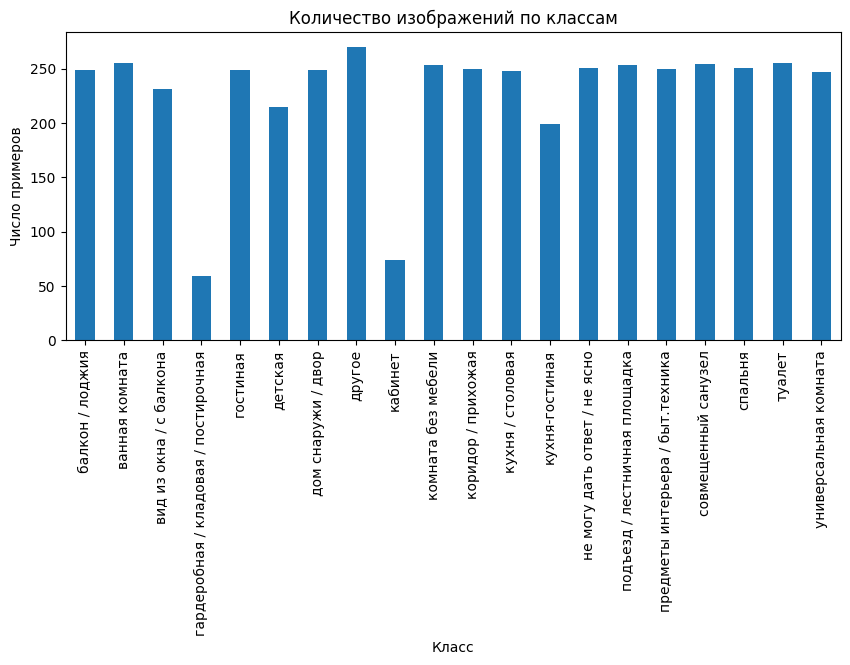

In [8]:
import matplotlib.pyplot as plt

# 1. Баланс классов
class_counts = train_df['label'].value_counts().sort_index()
plt.figure(figsize=(10, 4))
class_counts.plot(kind='bar')
plt.title("Количество изображений по классам")
plt.xlabel("Класс")
plt.ylabel("Число примеров")
plt.show()

# 2. Примеры картинок по классам
import random

def show_examples(df, image_root, class_id, n=6):
    subset = df[df['label'] == class_id].sample(min(n, (df['label'] == class_id).sum()))
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        img_path = os.path.join(image_root, f"{row['image_id_ext']}.jpg")
        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, n, i)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"Примеры класса {class_id}")
    plt.show()

**загрузка готовой DenseNet121 и получение предсказаний по train_loader**

In [9]:
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights

num_classes = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = densenet121(weights=DenseNet121_Weights.DEFAULT)

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)

model = model.to(device)

images, targets = next(iter(train_loader))
images, targets = images.to(device), targets.to(device)

with torch.no_grad():
    outputs = model(images)

print("targets shape:", targets.shape)
print("outputs shape:", outputs.shape)
print("target min/max:", targets.min().item(), targets.max().item())

device: cpu
targets shape: torch.Size([32])
outputs shape: torch.Size([32, 20])
target min/max: 0 19


**настраиваем лосс и оптимизатор**

In [10]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

# 1. обучаем только голову (classifier)
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

**Функция обучения и валидации**

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    for batch_idx, (images, targets) in enumerate(loader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

        # раз в N батчей печатать прогресс
        if batch_idx % 50 == 0:
            print(f"batch {batch_idx}/{len(loader)} loss={loss.item():.4f}")

    epoch_loss = running_loss / len(loader)
    epoch_f1 = calculate_macro_f1(all_targets, all_preds)
    return epoch_loss, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(loader):
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_f1 = calculate_macro_f1(all_targets, all_preds)
    return epoch_loss, epoch_f1, all_targets, all_preds

**Цикл по эпохам**

In [16]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

# 0. Убедимся, что папка для моделей доступна
os.makedirs("../outputs/models", exist_ok=True)

# 1. Функция потерь
criterion = nn.CrossEntropyLoss()

# 2. Сначала замораживаем все слои модели
for param in model.parameters():
    param.requires_grad = False

# 3. Размораживаем только последний классификатор (голову)
for param in model.classifier.parameters():
    param.requires_grad = True

# 4. Оптимизатор обучает только размороженные параметры (classifier)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
)

best_val_f1 = 0.0

print("Stage 1: обучаем только голову (classifier)")
for epoch in range(2):  # начнем с 2 эпох
    print(f"Epoch {epoch + 1}/2")

    #  Обучение на train 
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    #  Оценка на val 
    val_loss, val_f1, val_targets, val_preds = validate_one_epoch(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch + 1}/2 | "
        f"train_loss={train_loss:.4f}, train_macro_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f}, val_macro_f1={val_f1:.4f}"
    )

    # Если F1 на валидации улучшился - сохраняем лучшую модель
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        save_path = "../outputs/models/densenet121_head_best.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Saved best head-only model to {save_path}")

Stage 1: обучаем только голову (classifier)

Epoch 1/2
batch 0/143 loss=0.4973
batch 50/143 loss=0.4561
batch 100/143 loss=0.3928
Epoch 1/2 | train_loss=0.4014, train_macro_f1=0.8773 | val_loss=1.0281, val_macro_f1=0.6355
Saved best head-only model to ../outputs/models/densenet121_head_best.pth

Epoch 2/2
batch 0/143 loss=0.3590
batch 50/143 loss=0.4638
batch 100/143 loss=0.2209
Epoch 2/2 | train_loss=0.3274, train_macro_f1=0.8924 | val_loss=1.0843, val_macro_f1=0.6229


**fine-tuning всей сети**

In [14]:
import torch.nn as nn
import torch.optim as optim
import torch

# 1. Загружаем лучшую модель после Stage 1
checkpoint_path = "../outputs/models/densenet121_head_best.pth"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
print(f"Loaded weights from {checkpoint_path}")

# 2. Размораживаем все слои модели
for param in model.parameters():
    param.requires_grad = True

# 3. Новый оптимизатор: теперь обучаем все параметры, но с меньшим lr
optimizer_ft = optim.Adam(
    model.parameters(),
    lr=1e-4,   # меньше, чем 1e-3 на голове
)

best_val_f1_ft = 0.0

print("Stage 2: fine-tuning всей сети")
num_epochs_ft = 3  

for epoch in range(num_epochs_ft):
    print(f"Epoch {epoch + 1}/{num_epochs_ft}")

    #  Обучение на train 
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer_ft, device
    )

    # Оценка на val 
    val_loss, val_f1 = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs_ft} | "
        f"train_loss={train_loss:.4f}, train_macro_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f}, val_macro_f1={val_f1:.4f}"
    )

    # Сохраняем лучшую модель Stage 2
    if val_f1 > best_val_f1_ft:
        best_val_f1_ft = val_f1
        save_path = "../outputs/models/densenet121_best_finetuned.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Сохранена finetuned модель в {save_path}")

Loaded weights from ../outputs/models/densenet121_head_best.pth
Stage 2: fine-tuning всей сети
Epoch 1/3
batch 0/143 loss=1.6746
batch 50/143 loss=1.4700
batch 100/143 loss=1.3168
Epoch 1/3 | train_loss=1.2954, train_macro_f1=0.5395 | val_loss=1.1409, val_macro_f1=0.5568
Сохранена finetuned модель в ../outputs/models/densenet121_best_finetuned.pth
Epoch 2/3
batch 0/143 loss=0.9296
batch 50/143 loss=0.8698
batch 100/143 loss=0.7616
Epoch 2/3 | train_loss=0.8485, train_macro_f1=0.7040 | val_loss=1.0688, val_macro_f1=0.5919
Сохранена finetuned модель в ../outputs/models/densenet121_best_finetuned.pth
Epoch 3/3
batch 0/143 loss=0.6143
batch 50/143 loss=0.5904
batch 100/143 loss=0.6061
Epoch 3/3 | train_loss=0.6010, train_macro_f1=0.8009 | val_loss=0.9910, val_macro_f1=0.6322
Сохранена finetuned модель в ../outputs/models/densenet121_best_finetuned.pth


**Confusion matrix**

In [18]:
import torch
import numpy as np

# Загружаем лучшую finetuned модель
checkpoint_path = "../outputs/models/densenet121_best_finetuned.pth"
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print(f"Loaded finetuned model from {checkpoint_path}")

all_targets = []
all_preds = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

print("Shapes:", all_targets.shape, all_preds.shape)

Loaded finetuned model from ../outputs/models/densenet121_best_finetuned.pth
Shapes: (477,) (477,)


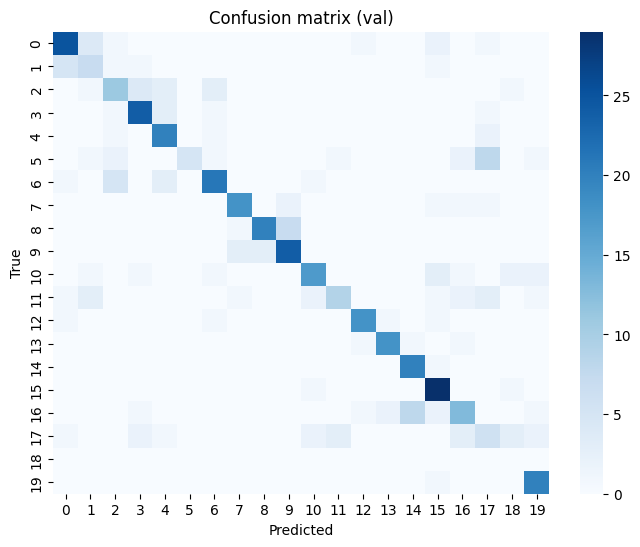

              precision    recall  f1-score   support

           0      0.735     0.735     0.735        34
           1      0.412     0.467     0.438        15
           2      0.500     0.478     0.489        23
           3      0.727     0.800     0.762        30
           4      0.667     0.833     0.741        24
           5      1.000     0.238     0.385        21
           6      0.724     0.677     0.700        31
           7      0.783     0.783     0.783        23
           8      0.870     0.714     0.784        28
           9      0.727     0.800     0.762        30
          10      0.739     0.607     0.667        28
          11      0.692     0.391     0.500        23
          12      0.857     0.818     0.837        22
          13      0.857     0.857     0.857        21
          14      0.690     0.952     0.800        21
          15      0.690     0.935     0.795        31
          16      0.565     0.464     0.510        28
          17      0.273    

C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# all_targets (истинные классы), all_preds (предсказанные)
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (val)")
plt.show()

print(classification_report(all_targets, all_preds, digits=3))

**Ошибки модели на валидации**

In [21]:
from PIL import Image

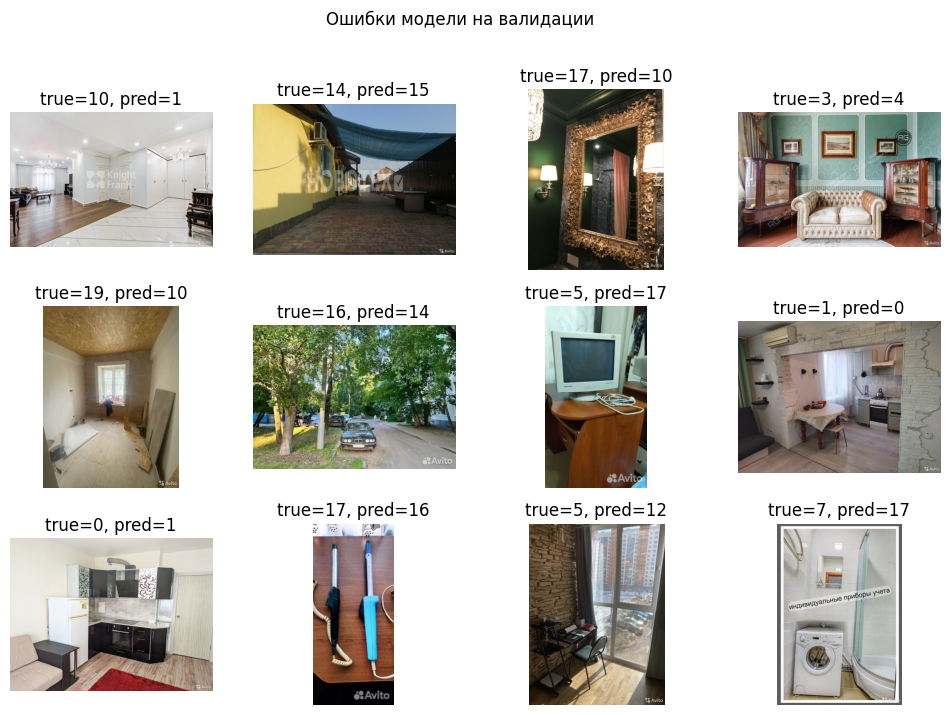

In [22]:
import numpy as np

val_targets = np.array(val_targets)
val_preds = np.array(val_preds)

wrong_mask = val_targets != val_preds
wrong_indices = np.where(wrong_mask)[0]

# Берем несколько ошибок
sample_idx = wrong_indices[:12]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_idx, 1):
    row = val_clean.iloc[idx]  
    img_path = os.path.join("../data/raw/val_images", f"{row['image_id_ext']}.jpg")
    img = Image.open(img_path).convert("RGB")
    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"true={val_targets[idx]}, pred={val_preds[idx]}")
plt.suptitle("Ошибки модели на валидации")
plt.show()

In [34]:
# Пропуски: модель НЕ распознала этот класс, хотя он есть
mask_missed = (all_targets == problem_class_id) & (all_preds != problem_class_id)
missed_idx = np.where(mask_missed)[0]

# Ложные срабатывания: модель говорит, что это problem_class, но на самом деле другой
mask_false_pos = (all_targets != problem_class_id) & (all_preds == problem_class_id)
false_pos_idx = np.where(mask_false_pos)[0]

print(f"Класс {problem_class_id}:")
print("Пропусков (true=class, pred!=class):", len(missed_idx))
print("Ложных срабатываний (true!=class, pred=class):", len(false_pos_idx))

Класс 17:
Пропусков (true=class, pred!=class): 17
Ложных срабатываний (true!=class, pred=class): 16


**Визуализация**

**-------Пробуем вторую стадию обучения чуть подкрутить--------**

In [48]:
train_df, train_clean, train_dropped = clean_csv(
    "../data/raw/train_df.csv",
    "../data/raw/train_images",
    "../data/raw/train_df_clean.csv",
)

print(train_clean.shape)

(4562, 6)


,item_id,image,image_id_ext,result,label,ratio
0,1375153252730,http://labelimages.avito.ru/16028356846.jpg,16028356846,9,совмещенный санузел,1.000000
1,1375170002401,http://labelimages.avito.ru/16029739656.jpg,16029739656,1,кухня-гостиная,0.666667
2,1342634751186,http://labelimages.avito.ru/15209120394.jpg,15209120394,10,коридор / прихожая,1.000000
3,1351692753345,http://labelimages.avito.ru/15233743709.jpg,15233743709,19,комната без мебели,1.000000
4,1356036751042,http://labelimages.avito.ru/15243147894.jpg,15243147894,17,предметы интерьера / быт.техника,0.666667


In [49]:
# подсчёт частот и создание weighted loss
import numpy as np
import torch
import torch.nn as nn

# Частоты классов по train
train_labels = train_clean['result'].values  # числовые ID 0–18
num_classes = 19

class_counts = np.bincount(train_labels, minlength=num_classes)
print("class_counts:", class_counts)

# Веса классов: weight ∝ 1 / count
eps = 1e-6
class_weights = 1.0 / (class_counts + eps)
class_weights = class_weights / class_weights.sum() * num_classes

print("class_weights:", class_weights)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)

class_counts: [248 199 247 249 251  74 215 255 255 254 250  59 249 231 249 253 270 250
 251 253]
class_weights: [0.73698775 0.91845709 0.7399715  0.73402796 0.72817913 2.46990486
 0.8501068  0.71675671 0.71675671 0.71957859 0.73109185 3.09784677
 0.73402796 0.79122494 0.73402796 0.72242277 0.6769369  0.73109185
 0.72817913 0.72242277]


In [51]:
import torch.optim as optim

state_dict = torch.load("../outputs/models/densenet121_best_finetuned.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)

for p in model.parameters():
    p.requires_grad = True

optimizer_ft2 = optim.Adam(model.parameters(), lr=5e-5)

best_val_f1_ft2 = 0.0
num_epochs_ft2 = 3

for epoch in range(num_epochs_ft2):
    print(f"\nEpoch {epoch + 1}/{num_epochs_ft2}")

    train_loss, train_f1 = train_one_epoch(
        model, train_loader, criterion_weighted, optimizer_ft2, device
    )
    val_loss, val_f1, val_targets, val_preds = validate_one_epoch(
        model, val_loader, criterion_weighted, device
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs_ft2} | "
        f"train_loss={train_loss:.4f}, train_macro_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f}, val_macro_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1_ft2:
        best_val_f1_ft2 = val_f1
        save_path = "../outputs/models/densenet121_best_finetuned_weighted.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Saved best weighted finetuned model to {save_path}")


Epoch 1/3
batch 0/143 loss=0.4586
batch 50/143 loss=0.3797
batch 100/143 loss=0.3888
Epoch 1/3 | train_loss=0.4499, train_macro_f1=0.8768 | val_loss=1.2030, val_macro_f1=0.6243
Saved best weighted finetuned model to ../outputs/models/densenet121_best_finetuned_weighted.pth

Epoch 2/3
batch 0/143 loss=0.2610
batch 50/143 loss=0.2172
batch 100/143 loss=0.2459
Epoch 2/3 | train_loss=0.3210, train_macro_f1=0.9263 | val_loss=1.2019, val_macro_f1=0.6397
Saved best weighted finetuned model to ../outputs/models/densenet121_best_finetuned_weighted.pth

Epoch 3/3
batch 0/143 loss=0.3070
batch 50/143 loss=0.1958
batch 100/143 loss=0.2303
Epoch 3/3 | train_loss=0.2422, train_macro_f1=0.9513 | val_loss=1.2006, val_macro_f1=0.6618
Saved best weighted finetuned model to ../outputs/models/densenet121_best_finetuned_weighted.pth


**Собиарем новый чекпоинт**

In [52]:
# загружаем лучший weighted чекпоинт
state_dict = torch.load("../outputs/models/densenet121_best_finetuned_weighted.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

all_targets = []
all_preds = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

In [53]:
from sklearn.metrics import classification_report

print(classification_report(all_targets, all_preds, digits=3))

              precision    recall  f1-score   support

           0      0.824     0.824     0.824        34
           1      0.438     0.467     0.452        15
           2      0.500     0.435     0.465        23
           3      0.767     0.767     0.767        30
           4      0.704     0.792     0.745        24
           5      0.700     0.333     0.452        21
           6      0.741     0.645     0.690        31
           7      0.857     0.783     0.818        23
           8      0.759     0.786     0.772        28
           9      0.677     0.700     0.689        30
          10      0.792     0.679     0.731        28
          11      0.722     0.565     0.634        23
          12      0.900     0.818     0.857        22
          13      0.818     0.857     0.837        21
          14      0.741     0.952     0.833        21
          15      0.818     0.871     0.844        31
          16      0.750     0.536     0.625        28
          17      0.333    

C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [58]:
from sklearn.metrics import classification_report, f1_score

labels_no18 = [i for i in range(20) if i != 18]

print(classification_report(all_targets, all_preds, labels=labels_no18, digits=3))

macro_f1_no18 = f1_score(all_targets, all_preds, labels=labels_no18, average="macro")
print("macro F1 (без класса 18):", macro_f1_no18)

              precision    recall  f1-score   support

           0      0.824     0.824     0.824        34
           1      0.438     0.467     0.452        15
           2      0.500     0.435     0.465        23
           3      0.767     0.767     0.767        30
           4      0.704     0.792     0.745        24
           5      0.700     0.333     0.452        21
           6      0.741     0.645     0.690        31
           7      0.857     0.783     0.818        23
           8      0.759     0.786     0.772        28
           9      0.677     0.700     0.689        30
          10      0.792     0.679     0.731        28
          11      0.722     0.565     0.634        23
          12      0.900     0.818     0.857        22
          13      0.818     0.857     0.837        21
          14      0.741     0.952     0.833        21
          15      0.818     0.871     0.844        31
          16      0.750     0.536     0.625        28
          17      0.333    

In [70]:
import torch.optim as optim

state_dict = torch.load(
    "../outputs/models/densenet121_best_finetuned.pth",
    map_location=device,
)
model.load_state_dict(state_dict)
model.to(device)

for p in model.parameters():
    p.requires_grad = True

optimizer_ft_boost5 = optim.Adam(model.parameters(), lr=3e-5)
num_epochs_ft_boost5 = 2
best_val_f1_boost5 = -1.0

print("Fine-tune: boost класса 5")

for epoch in range(num_epochs_ft_boost5):
    print(f"\nEpoch {epoch + 1}/{num_epochs_ft_boost5}")

    train_loss, train_f1 = train_one_epoch(
        model,
        train_loader,              # можешь оставить текущий или включить weighted sampler
        criterion_weighted_boost5, # CrossEntropyLoss с новыми весами
        optimizer_ft_boost5,
        device,
    )

    val_loss, val_f1, _, _ = validate_one_epoch(
        model,
        val_loader,
        criterion_weighted_boost5,
        device,
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs_ft_boost5} | "
        f"train_loss={train_loss:.4f}, train_macro_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.44f}, val_macro_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1_boost5:
        best_val_f1_boost5 = val_f1
        save_path = "../outputs/models/densenet121_best_finetuned_boost5.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Saved best model with boosted class 5 weight to {save_path}")

Fine-tune: boost класса 5

Epoch 1/2
batch 0/143 loss=0.5869
batch 50/143 loss=0.3388
batch 100/143 loss=0.5860
Epoch 1/2 | train_loss=0.4355, train_macro_f1=0.8910 | val_loss=1.16511806249618521391653302998747676610946655, val_macro_f1=0.6636
Saved best model with boosted class 5 weight to ../outputs/models/densenet121_best_finetuned_boost5.pth

Epoch 2/2
batch 0/143 loss=0.4277
batch 50/143 loss=0.4998
batch 100/143 loss=0.3097
Epoch 2/2 | train_loss=0.3433, train_macro_f1=0.9180 | val_loss=1.19806180795033778707647798000834882259368896, val_macro_f1=0.6431


In [75]:
# классификейшн репорт
import numpy as np
from sklearn.metrics import classification_report, f1_score

state_dict = torch.load(
    "../outputs/models/densenet121_best_finetuned_boost5.pth",
    map_location=device,
)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

all_targets, all_preds = [], []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

print("=== classification_report после boost класса 5 ===")
print(classification_report(all_targets, all_preds, digits=3))

labels_no18 = [i for i in range(20) if i != 18]
macro_f1_no18 = f1_score(
    all_targets, all_preds,
    labels=labels_no18,
    average="macro",
)
print("macro F1 (без класса 18):", macro_f1_no18)

=== classification_report после boost класса 5 ===
              precision    recall  f1-score   support

           0      0.885     0.676     0.767        34
           1      0.389     0.467     0.424        15
           2      0.625     0.435     0.513        23
           3      0.667     0.800     0.727        30
           4      0.679     0.792     0.731        24
           5      0.500     0.333     0.400        21
           6      0.724     0.677     0.700        31
           7      0.818     0.783     0.800        23
           8      0.828     0.857     0.842        28
           9      0.793     0.767     0.780        30
          10      0.760     0.679     0.717        28
          11      0.667     0.522     0.585        23
          12      0.870     0.909     0.889        22
          13      0.857     0.857     0.857        21
          14      0.714     0.952     0.816        21
          15      0.875     0.903     0.889        31
          16      0.737     0.

C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [76]:
# # **Попробуем прогнать с тест тайм аугументейшн** можно оставить как доп, прирост - 6 тысячных
# import torch
# import numpy as np
# from sklearn.metrics import classification_report

# model.eval()

# all_targets_tta = []
# all_preds_tta = []

# with torch.no_grad():
#     for images, targets in val_loader:
#         images = images.to(device)
#         targets = targets.to(device)

#         # 1. Прогоняем исходные изображения
#         logits_orig = model(images)  # [B, 19]

#         # 2. Делаем горизонтальный флип в тензорном виде
#         images_flipped = torch.flip(images, dims=[3])  # переворот по ширине (W)

#         # 3. Прогоняем флипнутые
#         logits_flip = model(images_flipped)  # [B, 19]

#         # 4. Усредняем логиты
#         logits_avg = (logits_orig + logits_flip) / 2.0

#         # 5. Итоговый предсказанный класс
#         preds = logits_avg.argmax(dim=1)

#         all_targets_tta.extend(targets.cpu().numpy())
#         all_preds_tta.extend(preds.cpu().numpy())

# all_targets_tta = np.array(all_targets_tta)
# all_preds_tta = np.array(all_preds_tta)

# print("TTA classification report:")
# print(classification_report(all_targets_tta, all_preds_tta, digits=3))

TTA classification report:
              precision    recall  f1-score   support

           0      0.821     0.676     0.742        34
           1      0.389     0.467     0.424        15
           2      0.562     0.391     0.462        23
           3      0.667     0.800     0.727        30
           4      0.667     0.833     0.741        24
           5      0.533     0.381     0.444        21
           6      0.750     0.677     0.712        31
           7      0.810     0.739     0.773        23
           8      0.821     0.821     0.821        28
           9      0.793     0.767     0.780        30
          10      0.826     0.679     0.745        28
          11      0.619     0.565     0.591        23
          12      0.905     0.864     0.884        22
          13      0.857     0.857     0.857        21
          14      0.714     0.952     0.816        21
          15      0.879     0.935     0.906        31
          16      0.750     0.536     0.625        28


C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pantp\room_type_classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
